In [1]:
%matplotlib inline
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import gridspec
import numpy as np
from sklearn.metrics import cohen_kappa_score
from scipy.stats import spearmanr


# Set the style
sns.set_theme(style="whitegrid")

# Set general plot parameters for Overleaf (1-column A4)
plt.rcParams.update(
    {
        "figure.figsize": (3.3, 2.5),  # inches, ~1-column width
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 14,
        "pdf.fonttype": 42,  # vector fonts
        "ps.fonttype": 42,
    }
)

PATH = "./outputs"
SUBFOLDERS = ["achievement", "delinquency", "ptsd"]
LABELS = [
    "gpt-5-mini",
    "Qwen-3-30B",
    "Llama-3.3-70B",
    "Magistral-Small",
    "Qwen-Next-80B",
]
GROLTS_LABELS_OLD = [
    "1",
    "2",
    "3a",
    "3b",
    "3c",
    "4",
    "5",
    "6a",
    "6b",
    "7",
    "8",
    "9",
    "10",
    "11",
    "12",
    "13",
    "14a",
    "14b",
    "14c",
    "15",
    "16",
]
GROLTS_LABELS_NEW = [
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9",
    "10",
    "11",
    "12",
    "13",
    "14",
    "15",
    "16",
    "17",
    "18",
    "19",
]
ID_MAP = {
    0: 0,
    1: 1,
    2: 4,
    3: 5,
    4: 6,
    5: 7,
    6: 9,
    7: 10,
    8: 11,
    9: 12,
    10: 13,
    11: 13,
    12: 14,
    13: 14,
    14: 15,
    15: 16,
    16: 18,
    17: 19,
    18: 20,
}
INVERSE_ID_MAP = {
    0: [0],
    1: [1],
    4: [2],
    5: [3],
    6: [4],
    7: [5],
    9: [6],
    10: [7],
    11: [8],
    12: [9],
    13: [10, 11],
    14: [12, 13],
    15: [14],
    16: [15],
    18: [16],
    19: [17],
    20: [18],
}

In [2]:
def load_llm_accuracies(df_labels, files, mapping=None):
    data = {}

    for i, f in enumerate(files):
        df = pd.read_csv(f"{PATH}/{f}")
        
        if mapping:
            df["question_id_file"] = df["question_id"]
            # Map to human question_id for merging
            df["question_id"] = df["question_id"].map(mapping)
            df_merged = df.merge(
            df_labels, on=["paper_id", "question_id"], suffixes=("_pred", "_true")
        )
            df_merged["question_id"] = df_merged["question_id_file"]
            df_merged.drop(columns=["question_id_file"], inplace=True)

        else:
            df_merged = df.merge(
                df_labels, on=["paper_id", "question_id"], suffixes=("_pred", "_true")
            )
        df_merged["correct"] = (
            df_merged["answer_pred"] == df_merged["answer_true"]
        ).astype(int)
        acc = df_merged.groupby("question_id")["correct"].mean()
        data[LABELS[i]] = acc

    acc_df = pd.DataFrame(data).sort_index()
    acc_df.reset_index(inplace=True)

    return acc_df

In [3]:
# Load labels
df_labels = pd.read_csv(f"./human_labels/ptsd.csv", delimiter=";", dtype=int)
df_labels = df_labels.melt(
    id_vars=["paper_id"], var_name="question_id", value_name="answer"
)
df_labels["paper_id"] = df_labels["paper_id"].astype(int)
df_labels["question_id"] = df_labels["question_id"].astype(int)
df_labels["answer"] = df_labels["answer"].astype(int)
files = [
    f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_ptsd_1000_0.csv",
]
acc_df = load_llm_accuracies(df_labels, files)

In [4]:

# 1. Calculate the 'Mean LLM Accuracy' for column names in LABELS
acc_df['Mean LLM Accuracy'] = acc_df[LABELS].mean(axis=1)

# 2. Calculate 'Human Label Prevalence' for each question (assuming it's the mean of the human answer column)
human_prevalence = df_labels.groupby("question_id")["answer"].mean()
acc_df['Human Prevalence'] = human_prevalence # (Requires a rework of load_llm_accuracies)

# A. ALL ITEMS (n=21)
# X: Mean of the 'Mean LLM Accuracy' column (Grand Mean LLM Accuracy)
X_all = acc_df['Mean LLM Accuracy'].mean()
# Y: Standard Deviation of the 'Mean LLM Accuracy' column (SD of Question Accuracies)
Y_all = acc_df['Mean LLM Accuracy'].std()
# Z: Mean of the 'Human Prevalence' for all 21 questions (Placeholder)
Z_all = acc_df['Human Prevalence'].mean()

# B. SORT AND TERCILE SPLIT
# Sort questions by their mean LLM accuracy to determine terciles
acc_df_sorted = acc_df.sort_values(by='Mean LLM Accuracy', ascending=False)
tercile_size = len(acc_df_sorted) // 3

# C. HIGHEST-AGREEMENT TERCILE (Top 7 questions, since n=21)
highest_tercile = acc_df_sorted.head(tercile_size)
X_high = highest_tercile['Mean LLM Accuracy'].mean()
Y_high = highest_tercile['Mean LLM Accuracy'].std()
Z_high = highest_tercile['Human Prevalence'].mean()

# D. MIDDLE TERCILE (Next 7 questions)
middle_tercile = acc_df_sorted.iloc[tercile_size:2*tercile_size]
X_mid = middle_tercile['Mean LLM Accuracy'].mean()
Y_mid = middle_tercile['Mean LLM Accuracy'].std()
Z_mid = middle_tercile['Human Prevalence'].mean()

# E. LOWEST-AGREEMENT TERCILE (Bottom 7 questions)
lowest_tercile = acc_df_sorted.tail(len(acc_df_sorted) - 2*tercile_size) # Takes the remaining
X_low = lowest_tercile['Mean LLM Accuracy'].mean()
Y_low = lowest_tercile['Mean LLM Accuracy'].std()
Z_low = lowest_tercile['Human Prevalence'].mean()

table_data = {
    "Item group": ["All items ($n=21$)", "Highest-agreement tercile", "Middle tercile", "Lowest-agreement tercile"],
    "Mean Accuracy (X)": [X_all, X_high, X_mid, X_low],
    "SD (Y)": [Y_all, Y_high, Y_mid, Y_low],
    "Human label prevalence (Z)": [Z_all, Z_high, Z_mid, Z_low],
}
display(pd.DataFrame(table_data))

,Item group,Mean Accuracy (X),SD (Y),Human label prevalence (Z)
0,All items ($n=21$),0.683960,0.252842,0.449875
1,Highest-agreement tercile,0.929323,0.058911,0.642857
2,Middle tercile,0.730075,0.064797,0.488722
3,Lowest-agreement tercile,0.392481,0.183277,0.218045


In [5]:
long_df = pd.DataFrame()
# Load labels
for subfolder in ["ptsd"]:
    df_labels = pd.read_csv(f"./human_labels/{subfolder}.csv", delimiter=";", dtype=int)
    df_labels = df_labels.melt(
        id_vars=["paper_id"], var_name="question_id", value_name="answer"
    )
    df_labels["paper_id"] = df_labels["paper_id"].astype(int)
    df_labels["question_id"] = df_labels["question_id"].astype(int)
    df_labels["answer"] = df_labels["answer"].astype(int)

    files = [
        f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_{subfolder}_1000_0.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_{subfolder}_1000_0.csv",
        f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_{subfolder}_1000_0.csv",
        f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_{subfolder}_1000_0.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_{subfolder}_1000_0.csv",
    ]

    acc_df = load_llm_accuracies(df_labels, files)
    acc_df = acc_df[acc_df["question_id"] != 12]

    acc_df = acc_df.melt(
        id_vars="question_id",
        var_name="model",
        value_name="acc"
    )
    
    acc_df["dataset"] = subfolder
    long_df = pd.concat([long_df, acc_df], ignore_index=True)

summary = (
    long_df
    .groupby(["dataset", "question_id"])["acc"]
    .agg(mean="mean", sd="std", n="count")
    .reset_index()
)

# 95% CI
summary["ci"] = 1.96 * summary["sd"] / np.sqrt(summary["n"])

summary["rank"] = (
    summary.groupby("dataset")["mean"]
    .rank(method="first")
)

summary = summary.sort_values(["dataset", "rank"])

global_order = (
    summary.groupby("question_id")["mean"]
    .mean()
    .sort_values()
    .index
)

summary["rank"] = summary["question_id"].map(
    {q: i for i, q in enumerate(global_order)}
)

# merge rank back into long df
long_df = long_df.merge(summary[["question_id", "rank", "dataset"]], on=["question_id", "dataset"])

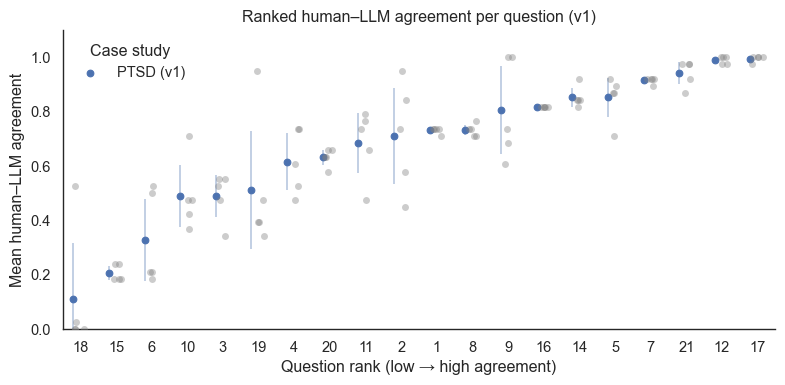

In [6]:
sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.2
)

fig, ax = plt.subplots(figsize=(8, 4))

datasets = summary["dataset"].unique()
offsets = np.linspace(-0.2, 0.2, len(datasets))

for offset, dataset in zip(offsets, datasets):
    subset = summary[summary["dataset"] == dataset].sort_values("rank")

    x = subset["rank"].values + offset
    y = subset["mean"].values
    ci = subset["ci"].values

    # scatter points
    ax.scatter(x, y, label=f"{dataset.upper()} (v1)")

    # CI band (vertical)
    ax.vlines(x, y - ci, y + ci, alpha=0.4)

sns.stripplot(
    data=long_df,
    x="rank",
    y="acc",
    color="gray",
    alpha=0.4,
    jitter=0.15,
    ax=ax
)

ax.set_ylim(0, 1.1)
ax.set_xlabel("Question rank (low → high agreement)")
ax.set_ylabel("Mean human–LLM agreement")

ax.set_xticks(range(len(global_order)))
ax.set_xticklabels([x + 1 for x in global_order])

ax.legend(title="Case study", frameon=False)
sns.despine()
ax.set_title("Ranked human–LLM agreement per question (v1)")

plt.tight_layout()
plt.savefig("./viz/ranked_item_agreement_v1.pdf")
plt.show()

summary_v1 = summary.copy()

In [7]:
acc_dfs = {}
# Load labels
for subfolder in SUBFOLDERS:
    df_labels = pd.read_csv(f"./human_labels/{subfolder}.csv", delimiter=";", dtype=int)
    df_labels = df_labels.melt(
        id_vars=["paper_id"], var_name="question_id", value_name="answer"
    )
    df_labels["paper_id"] = df_labels["paper_id"].astype(int)
    df_labels["question_id"] = df_labels["question_id"].astype(int)
    df_labels["answer"] = df_labels["answer"].astype(int)

    files = [
        f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_{subfolder}_1000_4.csv",
    ]

    acc_df = load_llm_accuracies(df_labels, files, mapping=None if subfolder != "ptsd" else ID_MAP)
    acc_dfs[subfolder] = acc_df

In [8]:
for subfolder, acc_df in acc_dfs.items():
    print("----", subfolder, "----", flush=True)
    # 1. Calculate the 'Mean LLM Accuracy' (Mean of all LLMs for each question)
    acc_df['Mean LLM Accuracy'] = acc_df[LABELS].mean(axis=1)

    # 2. Calculate 'Human Label Prevalence' for each question (assuming it's the mean of the human answer column)
    if subfolder == "ptsd":
        # here we need to use ID_MAP to ensure we get the right prevalences for the right question ids
        human_prevalence = df_labels.groupby("question_id")["answer"].mean()
        # now use ID_MAP to map back to the original question ids
        human_prevalence_mapped = pd.Series(
            {k: human_prevalence[v] for k, v in ID_MAP.items()}
        )
        acc_df["Human Prevalence"] = human_prevalence_mapped

        #acc_df.dropna(subset=["Human Prevalence"], inplace=True)
    else:
        human_prevalence = df_labels.groupby("question_id")["answer"].mean()
        acc_df["Human Prevalence"] = (
            human_prevalence  # (Requires a rework of load_llm_accuracies)
        )
    
    acc_df.drop(index=12, inplace=True)

    # A. ALL ITEMS (n=21)
    # X: Mean of the 'Mean LLM Accuracy' column (Grand Mean LLM Accuracy)
    X_all = acc_df["Mean LLM Accuracy"].mean()
    # Y: Standard Deviation of the 'Mean LLM Accuracy' column (SD of Question Accuracies)
    Y_all = acc_df["Mean LLM Accuracy"].std()
    # Z: Mean of the 'Human Prevalence' for all 21 questions (Placeholder)
    Z_all = acc_df["Human Prevalence"].mean()

    # B. SORT AND TERCILE SPLIT
    # Sort questions by their mean LLM accuracy to determine terciles
    acc_df_sorted = acc_df.sort_values(by="Mean LLM Accuracy", ascending=False)
    tercile_size = len(acc_df_sorted) // 3

    # C. HIGHEST-AGREEMENT TERCILE (Top 7 questions, since n=21)
    highest_tercile = acc_df_sorted.head(tercile_size)
    X_high = highest_tercile["Mean LLM Accuracy"].mean()
    Y_high = highest_tercile["Mean LLM Accuracy"].std()
    Z_high = highest_tercile["Human Prevalence"].mean()

    # D. MIDDLE TERCILE (Next 7 questions)
    middle_tercile = acc_df_sorted.iloc[tercile_size : 2 * tercile_size]
    X_mid = middle_tercile["Mean LLM Accuracy"].mean()
    Y_mid = middle_tercile["Mean LLM Accuracy"].std()
    Z_mid = middle_tercile["Human Prevalence"].mean()

    # E. LOWEST-AGREEMENT TERCILE (Bottom 7 questions)
    lowest_tercile = acc_df_sorted.tail(
        len(acc_df_sorted) - 2 * tercile_size
    )  # Takes the remaining
    X_low = lowest_tercile["Mean LLM Accuracy"].mean()
    Y_low = lowest_tercile["Mean LLM Accuracy"].std()
    Z_low = lowest_tercile["Human Prevalence"].mean()
    print(lowest_tercile.index.unique())

    table_data = {
        "Item group": [
            "All items ($n=18$)",
            "Highest-agreement tercile",
            "Middle tercile",
            "Lowest-agreement tercile",
        ],
        "Mean Accuracy (X)": [X_all, X_high, X_mid, X_low],
        "SD (Y)": [Y_all, Y_high, Y_mid, Y_low],
        "Human label prevalence (Z)": [Z_all, Z_high, Z_mid, Z_low],
    }
    display(pd.DataFrame(table_data))

---- achievement ----
Index([7, 10, 16, 1, 17, 13], dtype='int64')


,Item group,Mean Accuracy (X),SD (Y),Human label prevalence (Z)
0,All items ($n=18$),0.789583,0.174065,0.432749
1,Highest-agreement tercile,0.944792,0.013356,0.412281
2,Middle tercile,0.840625,0.070793,0.421053
3,Lowest-agreement tercile,0.583333,0.121428,0.464912


---- delinquency ----
Index([10, 1, 7, 16, 17, 13], dtype='int64')


,Item group,Mean Accuracy (X),SD (Y),Human label prevalence (Z)
0,All items ($n=18$),0.772372,0.198234,0.432749
1,Highest-agreement tercile,0.959459,0.018957,0.513158
2,Middle tercile,0.829730,0.061607,0.320175
3,Lowest-agreement tercile,0.527928,0.108629,0.464912


---- ptsd ----
Index([1, 6, 10, 17, 16, 13], dtype='int64')


,Item group,Mean Accuracy (X),SD (Y),Human label prevalence (Z)
0,All items ($n=18$),0.767544,0.179441,0.524854
1,Highest-agreement tercile,0.954386,0.031167,0.644737
2,Middle tercile,0.771930,0.040994,0.587719
3,Lowest-agreement tercile,0.576316,0.145009,0.342105


In [9]:
long_df = pd.DataFrame()
# Load labels
for subfolder in SUBFOLDERS:
    df_labels = pd.read_csv(f"./human_labels/{subfolder}.csv", delimiter=";", dtype=int)
    df_labels = df_labels.melt(
        id_vars=["paper_id"], var_name="question_id", value_name="answer"
    )
    df_labels["paper_id"] = df_labels["paper_id"].astype(int)
    df_labels["question_id"] = df_labels["question_id"].astype(int)
    df_labels["answer"] = df_labels["answer"].astype(int)

    files = [
        f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_{subfolder}_1000_4.csv",
    ]

    acc_df = load_llm_accuracies(df_labels, files, mapping=None if subfolder != "ptsd" else ID_MAP)
    acc_df = acc_df[acc_df["question_id"] != 12]

    acc_df = acc_df.melt(
        id_vars="question_id",
        var_name="model",
        value_name="acc"
    )
    
    acc_df["dataset"] = subfolder
    long_df = pd.concat([long_df, acc_df], ignore_index=True)

summary = (
    long_df
    .groupby(["dataset", "question_id"])["acc"]
    .agg(mean="mean", sd="std", n="count")
    .reset_index()
)

# 95% CI
summary["ci"] = 1.96 * summary["sd"] / np.sqrt(summary["n"])

summary["rank"] = (
    summary.groupby("dataset")["mean"]
    .rank(method="first")
)

summary = summary.sort_values(["dataset", "rank"])

global_order = (
    summary.groupby("question_id")["mean"]
    .mean()
    .sort_values()
    .index
)

summary["rank"] = summary["question_id"].map(
    {q: i for i, q in enumerate(global_order)}
)

# merge rank back into long df
long_df = long_df.merge(summary[["question_id", "rank", "dataset"]], on=["question_id", "dataset"])

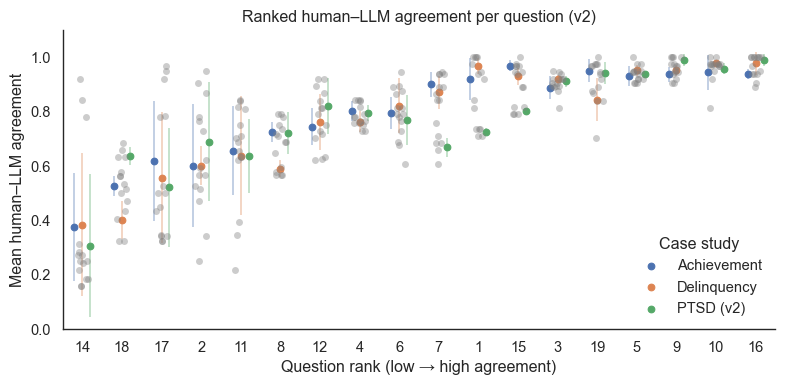

In [10]:
sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.2
)

fig, ax = plt.subplots(figsize=(8, 4))

datasets = summary["dataset"].unique()
offsets = np.linspace(-0.2, 0.2, len(datasets))

for offset, dataset in zip(offsets, datasets):
    subset = summary[summary["dataset"] == dataset].sort_values("rank")

    x = subset["rank"].values + offset
    y = subset["mean"].values
    ci = subset["ci"].values

    # scatter points
    sc = ax.scatter(x, y, label=dataset.capitalize() if dataset != "ptsd" else f"{dataset.upper()} (v2)")

    color = sc.get_facecolor()[0]

    # CI band (vertical)
    ax.vlines(x, y - ci, y + ci, color=color, alpha=0.4)

sns.stripplot(
    data=long_df,
    x="rank",
    y="acc",
    color="gray",
    alpha=0.4,
    jitter=0.15,
    ax=ax
)

ax.set_ylim(0, 1.1)
ax.set_xlabel("Question rank (low → high agreement)")
ax.set_ylabel("Mean human–LLM agreement")

ax.set_xticks(range(len(global_order)))
ax.set_xticklabels([x + 1 for x in global_order])

ax.legend(title="Case study", frameon=False)
sns.despine()
ax.set_title("Ranked human–LLM agreement per question (v2)")

plt.tight_layout()
plt.savefig("./viz/ranked_item_agreement_v2.pdf")
plt.show()


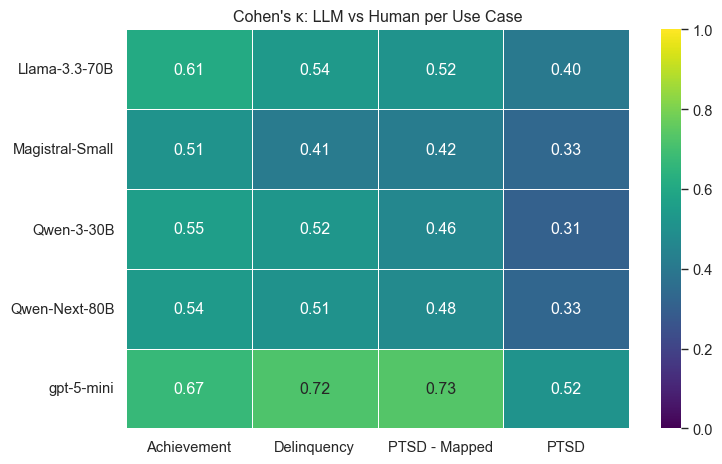

In [11]:
def build_rater_table(df_labels, files, mapping=None):
    """
    Returns a DataFrame with columns:
    paper_id, question_id, human, <model1>, <model2>, ..., <model6>
    """
    # Start with human labels
    df = df_labels.rename(columns={"answer": "human"})

    if mapping:
        # Prepare list of groups
        groups = []

        df["question_id_file"] = df["question_id"]

        for old_id, new_ids in mapping.items():
            sub_df = df[df["question_id_file"] == old_id].copy()
            for new_id in new_ids:
                # Select rows with this new_id
                sub_df["question_id"] = new_id
                groups.append(sub_df)

        # Concatenate all groups
        df = pd.concat(groups, ignore_index=True)
        df.drop(columns=["question_id_file"], inplace=True)

    # Load each model and join on paper_id + question_id
    for i, f in enumerate(files):
        modelname = LABELS[i]
        df2 = pd.read_csv(f"{PATH}/{f}")

        df2 = df2.rename(columns={"answer": modelname})
        df2 = df2[["paper_id", "question_id", modelname]]

        df = df.merge(df2, on=["paper_id", "question_id"], how="left")

    return df

def compute_kappa_llm_vs_human(df_raters):
    """
    Returns a dict: modelname -> Cohen's kappa with human
    """
    kappas = {}
    for modelname in LABELS:
        k = cohen_kappa_score(df_raters["human"], df_raters[modelname])
        kappas[modelname] = k
    return kappas


heatmap_data = []
case_labels = {
    "achievement": "Achievement",
    "delinquency": "Delinquency",
    "ptsd": "PTSD"}

for subfolder in SUBFOLDERS:
    # Load human labels
    df_labels = pd.read_csv(f"./human_labels/{subfolder}.csv", delimiter=";", dtype=int)
    df_labels = df_labels.melt(id_vars=["paper_id"], var_name="question_id", value_name="answer")
    df_labels["paper_id"] = df_labels["paper_id"].astype(int)
    df_labels["question_id"] = df_labels["question_id"].astype(int)

    # File paths
    files = [
        f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_{subfolder}_1000_4.csv",
    ]

    # Build rater table
    df_raters = build_rater_table(df_labels, files, mapping=None if subfolder != "ptsd" else INVERSE_ID_MAP)
    clean_df = df_raters.dropna()
    # drop rows for question_id == 12
    clean_df = clean_df[clean_df["question_id"] != 12]

    # Compute Cohen's kappa vs human
    kappa_dict = compute_kappa_llm_vs_human(clean_df)

    # Add to heatmap data
    for model, kappa in kappa_dict.items():
        heatmap_data.append({
            "Use case": case_labels[subfolder] if subfolder != "ptsd" else "PTSD - Mapped",
            "Model": model,
            "Cohen_kappa": kappa
        })

# Load human labels
df_labels = pd.read_csv(f"./human_labels/ptsd.csv", delimiter=";", dtype=int)
df_labels = df_labels.melt(id_vars=["paper_id"], var_name="question_id", value_name="answer")
df_labels["paper_id"] = df_labels["paper_id"].astype(int)
df_labels["question_id"] = df_labels["question_id"].astype(int)
# File paths
files = [
    f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_ptsd_1000_0.csv",
]
# Build rater table
df_raters = build_rater_table(df_labels, files, mapping=None)
clean_df = df_raters.dropna()

# drop rows for question_id == 12
clean_df = clean_df[clean_df["question_id"] != 12]

# Compute Cohen's kappa vs human
kappa_dict = compute_kappa_llm_vs_human(clean_df)
# Add to heatmap data
for model, kappa in kappa_dict.items():
    heatmap_data.append({
        "Use case": "PTSD",
        "Model": model,
        "Cohen_kappa": kappa
    })


# Convert to DataFrame
heatmap_df = pd.DataFrame(heatmap_data)

# Pivot to wide format for seaborn
heatmap_wide = heatmap_df.pivot(index="Model", columns="Use case", values="Cohen_kappa")

heatmap_wide = heatmap_wide[["Achievement", "Delinquency", "PTSD - Mapped", "PTSD"]]

# Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
sns.heatmap(
    heatmap_wide,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    vmin=0,
    vmax=1,
)
plt.title("Cohen's κ: LLM vs Human per Use Case")
plt.tight_layout()
plt.xlabel("")
plt.ylabel("")
plt.show()

In [12]:
def fleiss_kappa(ratings_matrix):
    N, k = ratings_matrix.shape

    n_per_item = ratings_matrix.sum(axis=1)
    if not np.all(n_per_item == n_per_item[0]):
        raise ValueError("All items must have the same number of raters")

    n = n_per_item[0]

    p = ratings_matrix.sum(axis=0) / (N * n)
    P = (ratings_matrix * (ratings_matrix - 1)).sum(axis=1) / (n * (n - 1))

    P_bar = P.mean()
    P_e = np.sum(p ** 2)

    if P_e == 1:
        return np.nan

    return (P_bar - P_e) / (1 - P_e)

def compute_fleiss_kappa(df_raters):
    """
    Convert binary ratings to category count matrix for Fleiss' kappa.
    """
    raters = ["human"] + LABELS if "human" in df_raters.columns else LABELS
    # Matrix N_items × 2 categories
    mat = []

    for _, row in df_raters[raters].iterrows():
        count_1 = row.sum()
        count_0 = len(raters) - count_1
        mat.append([count_0, count_1])

    mat = np.array(mat)
    return fleiss_kappa(mat)

In [13]:
for subfolder in SUBFOLDERS:
    # Load human labels
    df_labels = pd.read_csv(f"./human_labels/{subfolder}.csv", delimiter=";", dtype=int)
    df_labels = df_labels.melt(id_vars=["paper_id"], var_name="question_id", value_name="answer")
    df_labels["paper_id"] = df_labels["paper_id"].astype(int)
    df_labels["question_id"] = df_labels["question_id"].astype(int)

    # File paths
    files = [
        f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_{subfolder}_1000_4.csv",
    ]

    # Build rater table
    df_raters = build_rater_table(df_labels, files, mapping=None if subfolder != "ptsd" else INVERSE_ID_MAP)
    clean_df = df_raters.dropna()
    # drop rows for question_id == 12
    clean_df = clean_df[clean_df["question_id"] != 12]

    # Compute Cohen's kappa vs human
    print("Fleiss' kappa for", (subfolder if subfolder != "ptsd" else "ptsd - mapped"), ":", compute_fleiss_kappa(clean_df))

    # Add to heatmap data
    for model, kappa in kappa_dict.items():
        heatmap_data.append({
            "Use case": case_labels[subfolder] if subfolder != "ptsd" else "PTSD - Mapped",
            "Model": model,
            "Cohen_kappa": kappa
        })

# Load human labels
df_labels = pd.read_csv(f"./human_labels/ptsd.csv", delimiter=";", dtype=int)
df_labels = df_labels.melt(id_vars=["paper_id"], var_name="question_id", value_name="answer")
df_labels["paper_id"] = df_labels["paper_id"].astype(int)
df_labels["question_id"] = df_labels["question_id"].astype(int)
# File paths
files = [
    f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_ptsd_1000_0.csv",
]
# Build rater table
df_raters = build_rater_table(df_labels, files, mapping=None if subfolder != "ptsd" else INVERSE_ID_MAP)
clean_df = df_raters.dropna()
# drop rows for question_id == 12
clean_df = clean_df[clean_df["question_id"] != 12]
# Compute Cohen's kappa vs human
print("Fleiss' kappa for ptsd:", compute_fleiss_kappa(clean_df))
# Add to heatmap data
for model, kappa in kappa_dict.items():
    heatmap_data.append({
        "Use case": "PTSD",
        "Model": model,
        "Cohen_kappa": kappa
    })

Fleiss' kappa for achievement : 0.6006663471111985
Fleiss' kappa for delinquency : 0.6106933982033249
Fleiss' kappa for ptsd - mapped : 0.6011088684821396
Fleiss' kappa for ptsd: 0.41162966854991007


In [14]:
acc_dfs = {}
# Load labels
for subfolder in SUBFOLDERS:
    df_labels = pd.read_csv(f"./human_labels/{subfolder}.csv", delimiter=";", dtype=int)
    df_labels = df_labels.melt(
        id_vars=["paper_id"], var_name="question_id", value_name="answer"
    )
    df_labels["paper_id"] = df_labels["paper_id"].astype(int)
    df_labels["question_id"] = df_labels["question_id"].astype(int)
    df_labels["answer"] = df_labels["answer"].astype(int)

    files = [
        f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_{subfolder}_1000_4.csv",
    ]

    acc_df = load_llm_accuracies(df_labels, files, mapping=None if subfolder != "ptsd" else ID_MAP)
    acc_df = acc_df[acc_df["question_id"] != 12]
    acc_df['Mean LLM Accuracy'] = acc_df[LABELS].mean(axis=1)
    acc_dfs[subfolder] = acc_df

In [15]:
tercile_mapping_per_dataset = {}

for dataset_name, acc_df in acc_dfs.items():
    # Sort questions by mean LLM accuracy (descending: high → low)
    acc_df_sorted = acc_df.sort_values(by="Mean LLM Accuracy", ascending=False).reset_index(drop=True)
    
    n_questions = len(acc_df_sorted)
    tercile_size = n_questions // 3
    
    tercile_mapping = {}
    
    # Assign high-agreement tercile
    for qid in acc_df_sorted.iloc[:tercile_size]['question_id']:
        tercile_mapping[qid] = 'high'
    
    # Assign mid-agreement tercile
    for qid in acc_df_sorted.iloc[tercile_size:2*tercile_size]['question_id']:
        tercile_mapping[qid] = 'mid'
    
    # Assign low-agreement tercile (remaining questions)
    for qid in acc_df_sorted.iloc[2*tercile_size:]['question_id']:
        tercile_mapping[qid] = 'low'
    
    tercile_mapping_per_dataset[dataset_name if dataset_name != "ptsd" else "ptsd_mapped"] = tercile_mapping

df_labels = pd.read_csv(f"./human_labels/ptsd.csv", delimiter=";", dtype=int)
df_labels = df_labels.melt(
    id_vars=["paper_id"], var_name="question_id", value_name="answer"
)
df_labels["paper_id"] = df_labels["paper_id"].astype(int)
df_labels["question_id"] = df_labels["question_id"].astype(int)
df_labels["answer"] = df_labels["answer"].astype(int)
files = [
    f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_ptsd_1000_0.csv",
]
acc_df = load_llm_accuracies(df_labels, files)

acc_df['Mean LLM Accuracy'] = acc_df[LABELS].mean(axis=1)

# Sort questions by mean LLM accuracy (descending: high → low)
acc_df_sorted = acc_df.sort_values(by="Mean LLM Accuracy", ascending=False).reset_index(drop=True)

n_questions = len(acc_df_sorted)
tercile_size = n_questions // 3

tercile_mapping = {}

# Assign high-agreement tercile
for qid in acc_df_sorted.iloc[:tercile_size]['question_id']:
    tercile_mapping[qid] = 'high'

# Assign mid-agreement tercile
for qid in acc_df_sorted.iloc[tercile_size:2*tercile_size]['question_id']:
    tercile_mapping[qid] = 'mid'

# Assign low-agreement tercile (remaining questions)
for qid in acc_df_sorted.iloc[2*tercile_size:]['question_id']:
    tercile_mapping[qid] = 'low'

tercile_mapping_per_dataset["ptsd"] = tercile_mapping

In [16]:
dfs = {}

for subfolder in SUBFOLDERS:
    # Load human labels
    df_labels = pd.read_csv(f"./human_labels/{subfolder}.csv", delimiter=";", dtype=int)
    df_labels = df_labels.melt(id_vars=["paper_id"], var_name="question_id", value_name="answer")
    df_labels["paper_id"] = df_labels["paper_id"].astype(int)
    df_labels["question_id"] = df_labels["question_id"].astype(int)

    # File paths
    files = [
        f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_{subfolder}_1000_4.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_{subfolder}_1000_4.csv",
    ]

    # Build rater table
    df_raters = build_rater_table(df_labels, files, mapping=None if subfolder != "ptsd" else INVERSE_ID_MAP)
    dfs[subfolder if subfolder != "ptsd" else "ptsd_mapped"] = df_raters

df_labels = pd.read_csv(f"./human_labels/ptsd.csv", delimiter=";", dtype=int)
df_labels = df_labels.melt(id_vars=["paper_id"], var_name="question_id", value_name="answer")
df_labels["paper_id"] = df_labels["paper_id"].astype(int)
df_labels["question_id"] = df_labels["question_id"].astype(int)
# File paths
files = [
    f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_ptsd_1000_0.csv",
    f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_ptsd_1000_0.csv",
]
# Build rater table
df_raters = build_rater_table(df_labels, files, mapping=None)
dfs["ptsd"] = df_raters

In [17]:
# --- Step 1: Compute total scores per paper per rater ---
def total_scores(df):
    # pivot table: paper_id × rater, sum across question_id
    score_df = df.groupby('paper_id').sum().drop(columns=['question_id'])
    return score_df

# --- Step 2: Compute Spearman correlations between human and each LLM ---
def compute_spearman(score_df):
    human_scores = score_df['human']
    results = {}
    for col in score_df.columns:
        if col != 'human':
            rho, _ = spearmanr(human_scores, score_df[col])
            results[col] = rho
    return results

# --- Step 3: Rank correlations by question tercile ---
def tercile_rank_correlations(df, tercile_mapping):
    """
    df: original dataframe (paper_id × question_id × raters)
    tercile_mapping: dict {question_id: 'high'/'mid'/'low'}
    """
    results = {'high': {}, 'mid': {}, 'low': {}}
    for tercile in ['high', 'mid', 'low']:
        questions = [qid for qid, t in tercile_mapping.items() if t == tercile]
        if not questions:
            continue
        subset = df[df['question_id'].isin(questions)]
        score_df = subset.groupby('paper_id').sum().drop(columns=['question_id'])
        human_scores = score_df['human']
        for col in score_df.columns:
            if col != 'human':
                rho, _ = spearmanr(human_scores, score_df[col])
                results[tercile][col] = rho
    return results

# --- Step 4: Generate tables ---
def generate_table_spearman(all_results):
    """
    all_results: dict of {dataset_name: {LLM: rho}}
    """
    table = pd.DataFrame(all_results).T
    return table

def generate_table_tercile(all_tercile_results):
    """
    all_tercile_results: dict of {dataset_name: {'high': {LLM: rho}, ...}}
    """
    rows = []
    for dataset, tercile_dict in all_tercile_results.items():
        row = {'Dataset': dataset}
        for tercile in ['high','mid','low']:
            for llm, rho in tercile_dict.get(tercile, {}).items():
                row[f"{tercile}_{llm}"] = rho
        rows.append(row)
    table = pd.DataFrame(rows)
    return table

# --- Step 5: Optional scatterplot: human vs LLM total scores ---
def plot_human_vs_llm(score_df, dataset_name):
    plt.figure(figsize=(6,6))
    for col in score_df.columns:
        if col != 'human':
            plt.scatter(score_df['human'], score_df[col], label=col, alpha=0.7)
    plt.plot([score_df['human'].min(), score_df['human'].max()],
             [score_df['human'].min(), score_df['human'].max()],
             'k--', label='y=x')
    plt.xlabel("Human total score")
    plt.ylabel("LLM total score")
    plt.title(f"Human vs LLM total scores ({dataset_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Step 6: Run analysis for all datasets ---
all_spearman = {}
all_tercile = {}
all_kt = {}
for dataset_name, df in dfs.items():
    if dataset_name != "ptsd":
        # drop rows for question_id == 12 for v2
        df = df[df["question_id"] != 12]
    #print(dataset_name)
    score_df = total_scores(df)
    all_spearman[dataset_name] = compute_spearman(score_df)

    # Assume you have tercile mapping per dataset as dict {question_id: tercile}
    # Example: tercile_mapping = {0:'high', 1:'low', ...}
    all_tercile[dataset_name] = tercile_rank_correlations(df, tercile_mapping_per_dataset[dataset_name])
    
    # Optional scatterplot
    #plot_human_vs_llm(score_df, dataset_name)

# --- Step 7: Generate summary tables ---
spearman_table = generate_table_spearman(all_spearman)
tercile_table = generate_table_tercile(all_tercile)

print("Overall rank correlations (Spearman ρ):")
display(spearman_table)

print("\nRank correlations by question tercile:")
display(tercile_table)


Overall rank correlations (Spearman ρ):


,gpt-5-mini,Qwen-3-30B,Llama-3.3-70B,Magistral-Small,Qwen-Next-80B
achievement,0.555963,0.455886,0.716197,0.455237,0.361062
delinquency,0.645643,0.531126,0.563508,0.388834,0.446813
ptsd_mapped,0.405203,0.574009,0.564601,0.567885,0.652169
ptsd,0.629756,0.426890,0.468695,0.461477,0.585771



Rank correlations by question tercile:


,Dataset,high_gpt-5-mini,high_Qwen-3-30B,high_Llama-3.3-70B,high_Magistral-Small,high_Qwen-Next-80B,mid_gpt-5-mini,mid_Qwen-3-30B,mid_Llama-3.3-70B,mid_Magistral-Small,mid_Qwen-Next-80B,low_gpt-5-mini,low_Qwen-3-30B,low_Llama-3.3-70B,low_Magistral-Small,low_Qwen-Next-80B
0,achievement,0.913595,0.777934,0.800589,0.636646,0.641370,0.751127,0.648072,0.834520,0.575167,0.563283,0.019620,0.100304,-0.019589,-0.043205,-0.053578
1,delinquency,0.879633,0.778167,0.849850,0.594003,0.799705,0.758336,0.428235,0.596841,0.282399,0.633589,0.336152,-0.030379,-0.111503,0.185961,0.004022
2,ptsd_mapped,0.503591,0.727543,0.579370,0.655059,0.612065,0.538496,0.488360,0.507563,0.324596,0.715009,0.484664,0.379645,0.246825,0.439303,0.492270
3,ptsd,0.709179,0.672682,0.603257,0.566840,0.751737,0.576382,0.434845,0.472088,0.438241,0.495855,0.476730,0.126613,-0.056935,0.006287,0.032672


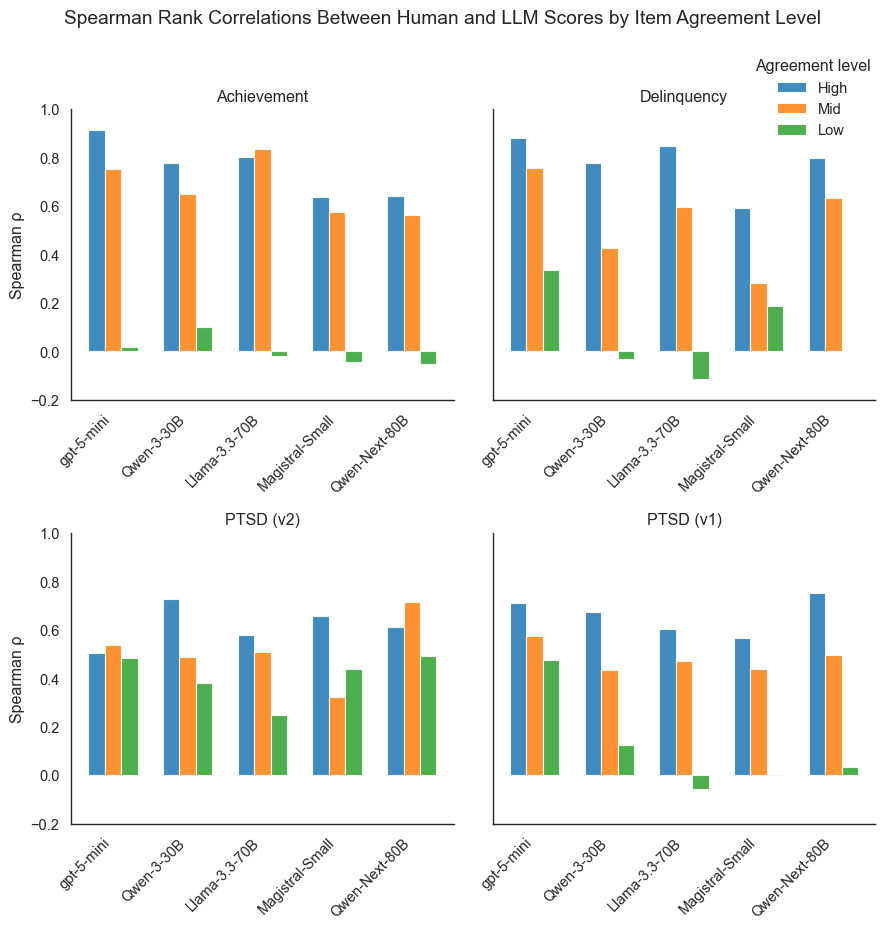

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_tercile_rank_correlation_multi(all_tercile_results):

    # --- Match style of other figure ---
    sns.set_theme(
        style="white",
        context="paper",
        font_scale=1.2
    )

    datasets = list(all_tercile_results.keys())
    terciles = ['high', 'mid', 'low']
    colors = {'high': '#1f77b4', 'mid': '#ff7f0e', 'low': '#2ca02c'}

    n_datasets = len(datasets)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(9, 9),
        sharey=True
    )

    if n_datasets == 1:
        axes = [axes]

    width = 0.22

    axes = axes.flatten()

    for ax, dataset in zip(axes, datasets):

        dataset_results = all_tercile_results[dataset]
        llms = list(next(iter(dataset_results.values())).keys())
        x = np.arange(len(llms))

        for i, tercile in enumerate(terciles):
            rho_values = [
                dataset_results.get(tercile, {}).get(llm, np.nan)
                for llm in llms
            ]

            ax.bar(
                x + i * width - width,
                rho_values,
                width=width,
                color=colors[tercile],
                alpha=0.85,
                label=f'{tercile.capitalize()}'
            )

        ax.set_xticks(x)
        ax.set_xticklabels(llms, rotation=45, ha='right')

        ax.set_title("PTSD (v2)" if dataset == "ptsd_mapped" else "PTSD (v1)" if dataset == "ptsd" else dataset.capitalize())

        ax.set_ylim(-0.2, 1)
        if dataset == datasets[0] or dataset == datasets[2]:  # left column
            ax.set_ylabel("Spearman ρ")

    # get handles from ONE axis only
    handles, labels = axes[0].get_legend_handles_labels()

    # remove all axis legends
    for ax in axes:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # create single figure-level legend
    fig.legend(
        handles[:3], labels[:3],   # only one set of terciles
        title="Agreement level",
        frameon=False,
        loc="upper right",
        bbox_to_anchor=(0.99, 0.99)
    )

    sns.despine()
    fig.suptitle(
        "Spearman Rank Correlations Between Human and LLM Scores by Item Agreement Level",
        y=1.03
    )

    plt.tight_layout()
    plt.savefig("./viz/rank_correlation.pdf", bbox_inches='tight')
    plt.show()

plot_tercile_rank_correlation_multi(all_tercile)


In [19]:
def load_llm_accuracies_with_human(df_labels, files):
    data = {}

    for f in files:
        df = pd.read_csv(f"{PATH}/{f}")
        filename = os.path.basename(f).replace(".csv", "")
        df_merged = df.merge(
            df_labels, on=["paper_id", "question_id"], suffixes=("_pred", "_true")
        )
        df_merged["correct"] = (
            df_merged["answer_pred"] == df_merged["answer_true"]
        ).astype(int)
        acc = df_merged.groupby("question_id")["correct"].mean()
        data[filename] = acc

    acc_df = pd.DataFrame(data).sort_index()

    # Compute proportion of 1's in human labels
    human_prop = df_labels.groupby("question_id")["answer"].mean()
    acc_df["Human"] = human_prop

    return acc_df


def load_llm_accuracies_with_human_with_old_new_map(df_labels, files):
    data = {}

    for f in files:
        df = pd.read_csv(f"{PATH}/{f}")
        filename = os.path.basename(f).replace(".csv", "")

        # Keep original file question_id for grouping
        df["file_question_id"] = df["question_id"]
        # Map to human question_id for merging
        df["question_id"] = df["question_id"].map(ID_MAP)

        df_merged = df.merge(
            df_labels, on=["paper_id", "question_id"], suffixes=("_pred", "_true")
        )
        df_merged["correct"] = (
            df_merged["answer_pred"] == df_merged["answer_true"]
        ).astype(int)

        # Group by the original file question_id to get 19 entries
        acc = df_merged.groupby("file_question_id")["correct"].mean()
        data[filename] = acc

    acc_df = pd.DataFrame(data).sort_index()

    # Add human proportion mapped to each file question_id
    human_prop = pd.Series(
        {
            k: df_labels[df_labels["question_id"] == v]["answer"].mean()
            for k, v in ID_MAP.items()
        }
    )
    acc_df["Human"] = human_prop

    return acc_df


def plot_accuracy_with_human(acc_df, subfolder, alt_map=False):
    # --- Data prep ---
    model_acc = acc_df.drop(columns="Human", errors="ignore")
    human = acc_df["Human"]

    # Compute summary stats
    row_means = model_acc.mean(axis=1)
    col_means = model_acc.mean(axis=0)
    overall_mean = model_acc.values.mean()

    # Pick the right set based on number of rows
    if model_acc.shape[0] == 19:
        y_labels = GROLTS_LABELS_NEW
    elif model_acc.shape[0] == 21:
        y_labels = [str(i+1) for i in range(len(GROLTS_LABELS_OLD))]

    # --- Figure layout ---
    fig = plt.figure(figsize=(11, 7))
    gs = gridspec.GridSpec(
        2,
        6,
        width_ratios=[4, 0.25, 0.1, 0.35, 0.5, 0.1],  # added a tiny spacer before human
        height_ratios=[4, 0.25],
        wspace=0.05,
        hspace=0.05,
    )

    # Axes
    ax_main = fig.add_subplot(gs[0, 0])
    ax_row = fig.add_subplot(gs[0, 1])
    ax_cbar = fig.add_subplot(gs[0, 2])
    ax_spacer = fig.add_subplot(gs[0, 3])  # empty axis
    ax_human = fig.add_subplot(gs[0, 4])
    ax_cbar_human = fig.add_subplot(gs[0, 5])
    ax_col = fig.add_subplot(gs[1, 0], sharex=ax_main)
    ax_corner1 = fig.add_subplot(gs[1, 1])
    ax_corner2 = fig.add_subplot(gs[1, 2])
    ax_corner3 = fig.add_subplot(gs[1, 3])
    ax_corner4 = fig.add_subplot(gs[1, 4])
    ax_corner5 = fig.add_subplot(gs[1, 5])

    # --- Main heatmap ---
    sns.heatmap(
        model_acc,
        ax=ax_main,
        vmin=0,
        vmax=1,
        cmap="rocket",
        cbar_ax=ax_cbar,
        cbar_kws={"label": "Accuracy"},
        annot=True,
        fmt=".2f",
        annot_kws={"size": 12},
        xticklabels=False,
    )
    ax_main.set_yticklabels(y_labels, rotation=0)
    if alt_map:
        ax_main.set_title(f"Per-Question Accuracy (PTSD v2)")
    else:
        ax_main.set_title(f"Per-Question Accuracy ({subfolder.capitalize() if subfolder != 'ptsd' else 'PTSD v1'})")
    ax_main.set_xlabel("")
    ax_main.set_ylabel("Question ID")
    ax_main.tick_params(
        bottom=False, top=False, labelbottom=False, left=True, labelleft=True
    )

    # --- Row mean strip ---
    row_mean_df = row_means.to_frame(name="Mean")
    sns.heatmap(
        row_mean_df,
        ax=ax_row,
        cmap="rocket",
        vmin=0,
        vmax=1,
        cbar=False,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 12},
        yticklabels=False,
        xticklabels=False,
        linewidths=0.5,
    )
    ax_row.set_facecolor("white")
    ax_row.set_ylabel("")
    ax_row.set_xlabel("")
    ax_row.tick_params(left=False, right=False, labelleft=False)

    # --- Column mean strip ---
    col_mean_df = pd.DataFrame(
        [col_means.values], columns=col_means.index, index=["Mean"]
    )
    sns.heatmap(
        col_mean_df,
        ax=ax_col,
        cmap="rocket",
        vmin=0,
        vmax=1,
        cbar=False,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 12},
        yticklabels=False,
        linewidths=0.5,
    )
    ax_col.set_facecolor("white")
    ax_col.set_xticklabels(LABELS, rotation=30, ha="center")
    ax_col.set_ylabel("")
    ax_col.set_xlabel("")

    # --- Bottom-right overall mean cell ---
    ax_corner1.text(
        0.5,
        0.5,
        f"{overall_mean:.2f}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
    )
    ax_corner1.set_xticks([])
    ax_corner1.set_yticks([])
    ax_corner1.set_facecolor("#f0f0f0")

    # --- Empty cells for symmetry ---
    ax_corner2.axis("off")
    ax_corner3.axis("off")
    ax_corner4.axis("off")
    ax_corner5.axis("off")
    ax_spacer.axis("off")

    # --- Human heatmap ---
    human_df = human.to_frame(name="Human")
    sns.heatmap(
        human_df,
        ax=ax_human,
        vmin=0,
        vmax=1,
        cmap=sns.light_palette("gray", as_cmap=True),
        annot=True,
        fmt=".2f",
        annot_kws={"size": 12},
        yticklabels=False,
        linewidths=0.5,
        cbar_kws={"label": "Proportion of 1's"},
        cbar_ax=ax_cbar_human,
    )
    ax_human.set_facecolor("white")
    ax_human.set_ylabel("")
    ax_human.set_xlabel("")
    ax_human.set_xticklabels([""], rotation=30, ha="center")

    # plt.tight_layout()
    if alt_map:
        plt.savefig(
            f"./viz/{subfolder}_combined_heatmap_mapped.pdf", bbox_inches="tight"
        )
    else:
        plt.savefig(f"./viz/{subfolder}_combined_heatmap.pdf", bbox_inches="tight")
    plt.show()

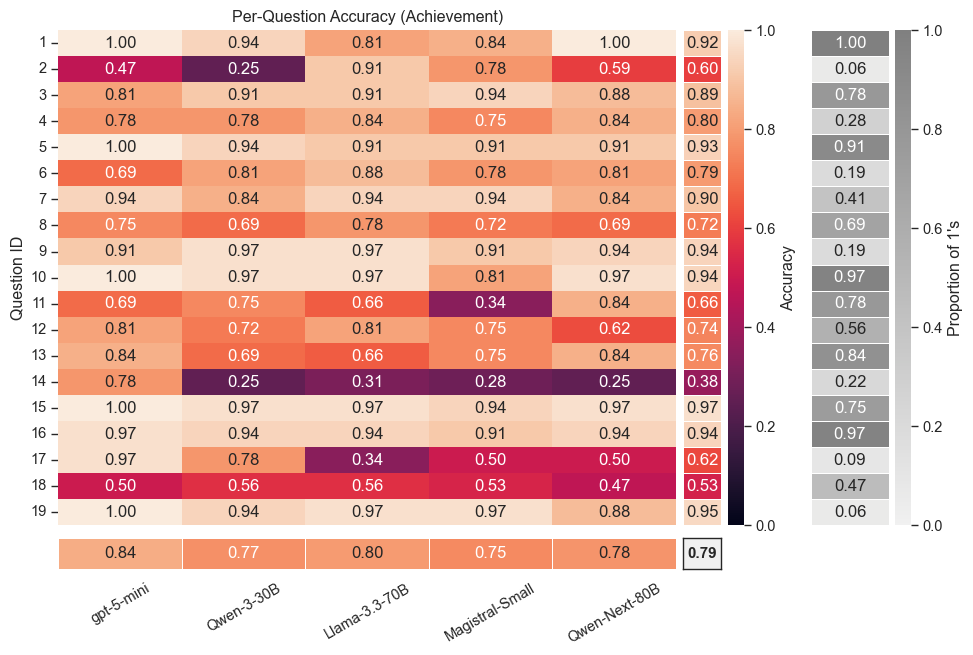

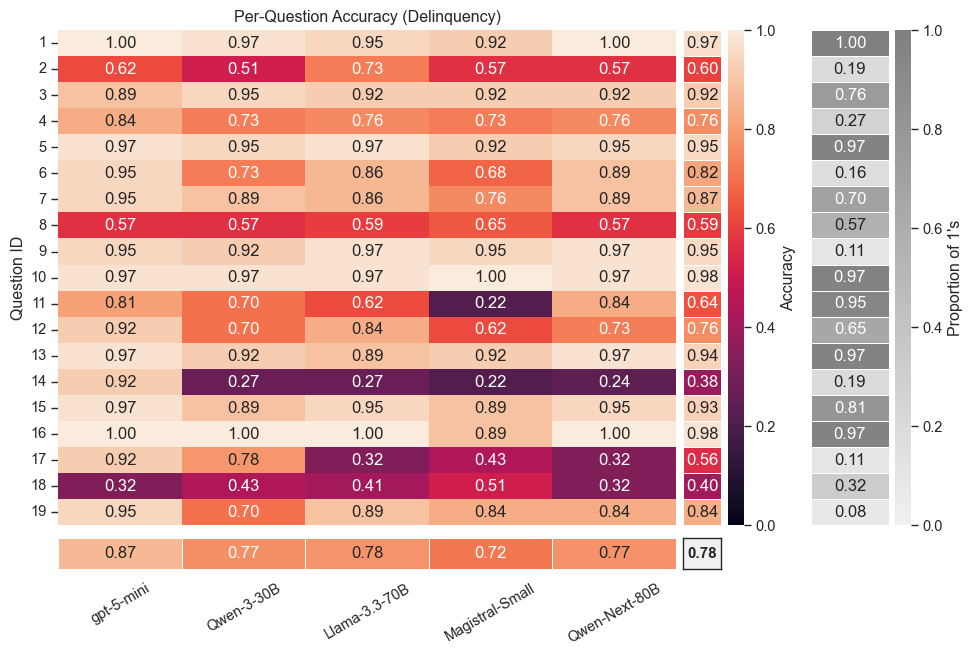

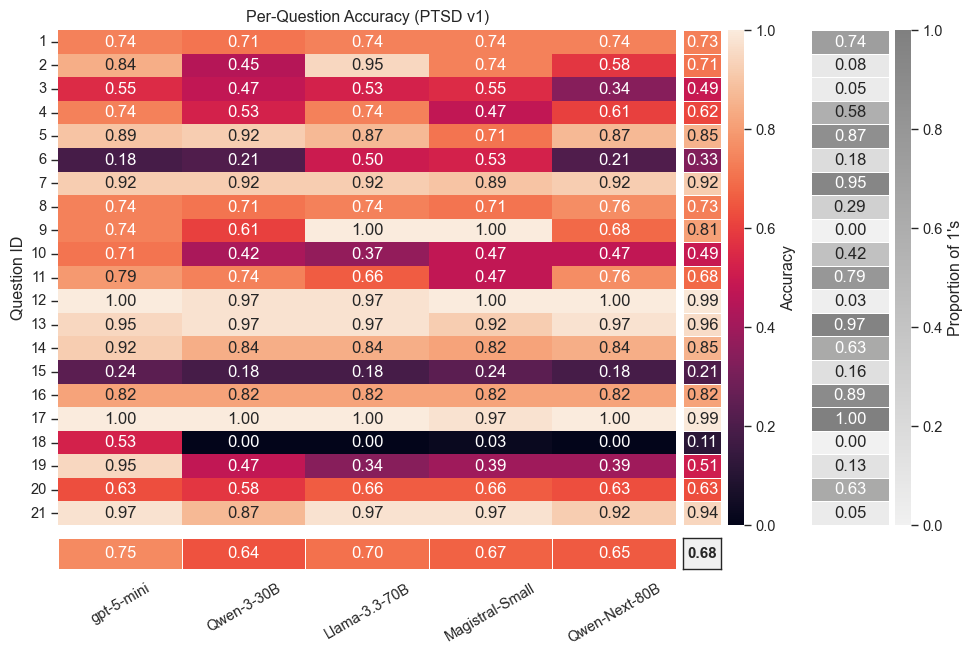

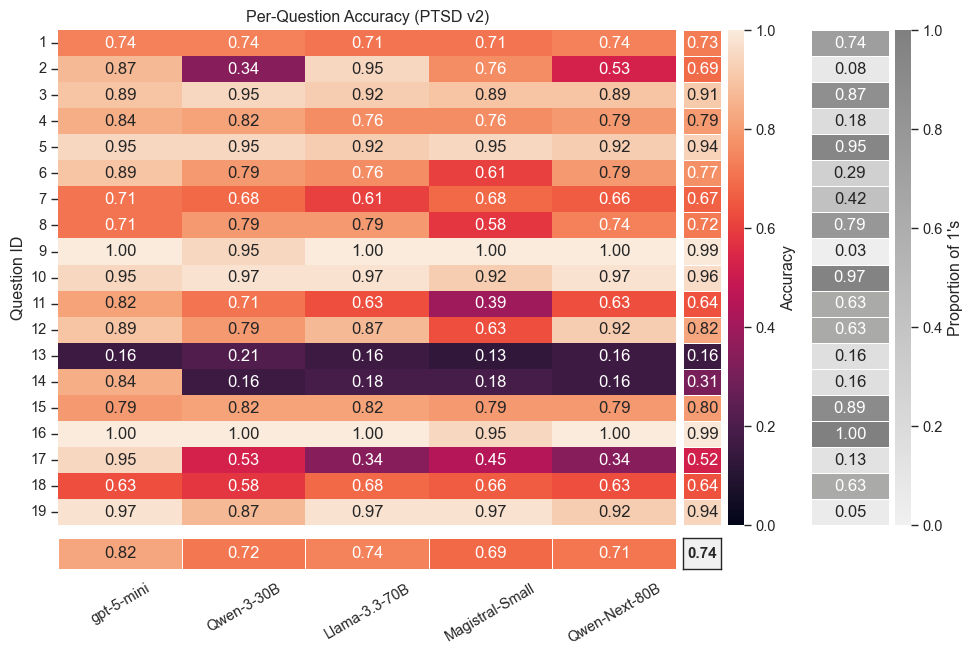

In [20]:
# Process all subfolders for unmapped cases (old questions for PTSD)
acc_dfs = []
# Load labels
for subfolder in SUBFOLDERS:
    df_labels = pd.read_csv(f"./human_labels/{subfolder}.csv", delimiter=";", dtype=int)
    df_labels = df_labels.melt(
        id_vars=["paper_id"], var_name="question_id", value_name="answer"
    )
    df_labels["paper_id"] = df_labels["paper_id"].astype(int)
    df_labels["question_id"] = df_labels["question_id"].astype(int)
    df_labels["answer"] = df_labels["answer"].astype(int)

    files = [
        f"Qwen_Qwen3-Embedding-8B_gpt-5-mini_{subfolder}_1000_{'0' if subfolder == 'ptsd' else '4'}.csv",
        #f"Qwen_Qwen3-Embedding-8B_microsoft_phi-4_{subfolder}_1000_{'0' if subfolder == 'ptsd' else '4'}.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_{subfolder}_1000_{'0' if subfolder == 'ptsd' else '4'}.csv",
        f"Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_{subfolder}_1000_{'0' if subfolder == 'ptsd' else '4'}.csv",
        f"Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_{subfolder}_1000_{'0' if subfolder == 'ptsd' else '4'}.csv",
        f"Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_{subfolder}_1000_{'0' if subfolder == 'ptsd' else '4'}.csv",
    ]

    acc_df = load_llm_accuracies_with_human(df_labels, files)
    plot_accuracy_with_human(acc_df, subfolder)
    acc_dfs.append(acc_df)

df_labels = pd.read_csv("./human_labels/ptsd.csv", delimiter=";", dtype=int)
df_labels = df_labels.melt(
    id_vars=["paper_id"], var_name="question_id", value_name="answer"
)
df_labels["paper_id"] = df_labels["paper_id"].astype(int)
df_labels["question_id"] = df_labels["question_id"].astype(int)
df_labels["answer"] = df_labels["answer"].astype(int)
files = [
    "Qwen_Qwen3-Embedding-8B_gpt-5-mini_ptsd_1000_4.csv",
    #"Qwen_Qwen3-Embedding-8B_microsoft_phi-4_ptsd_1000_4.csv",
    "Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_ptsd_1000_4.csv",
    "Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_ptsd_1000_4.csv",
    "Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_ptsd_1000_4.csv",
    "Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_ptsd_1000_4.csv",
]
acc_df = load_llm_accuracies_with_human_with_old_new_map(df_labels, files)
plot_accuracy_with_human(acc_df, "ptsd", alt_map=True)
acc_dfs.append(acc_df)

In [21]:
SUBFOLDER_LABELS = ["Achievement", "Delinquency", "PTSD v1", "PTSD v2"]

for i, acc_df in enumerate(acc_dfs):
    print(f"Mean accuracies per model ({SUBFOLDER_LABELS[i]}):")
    display(acc_df.mean().sort_values(ascending=False))

Mean accuracies per model (Achievement):


Qwen_Qwen3-Embedding-8B_gpt-5-mini_achievement_1000_4                           0.837171
Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_achievement_1000_4    0.796053
Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_achievement_1000_4     0.777961
Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_achievement_1000_4     0.773026
Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_achievement_1000_4       0.754934
Human                                                                           0.537829
dtype: float64

Mean accuracies per model (Delinquency):


Qwen_Qwen3-Embedding-8B_gpt-5-mini_delinquency_1000_4                           0.867710
Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_delinquency_1000_4    0.778094
Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_delinquency_1000_4     0.773826
Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_delinquency_1000_4     0.768137
Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_delinquency_1000_4       0.716927
Human                                                                           0.566145
dtype: float64

Mean accuracies per model (PTSD v1):


Qwen_Qwen3-Embedding-8B_gpt-5-mini_ptsd_1000_0                           0.754386
Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_ptsd_1000_0    0.703008
Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_ptsd_1000_0       0.671679
Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_ptsd_1000_0     0.652882
Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_ptsd_1000_0     0.637845
Human                                                                    0.449875
dtype: float64

Mean accuracies per model (PTSD v2):


Qwen_Qwen3-Embedding-8B_gpt-5-mini_ptsd_1000_4                           0.821330
Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_ptsd_1000_4    0.739612
Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_ptsd_1000_4     0.717452
Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_ptsd_1000_4     0.714681
Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_ptsd_1000_4       0.685596
Human                                                                    0.505540
dtype: float64